## STEP 1

In [16]:
import pandas as pd
data = pd.read_csv("project_dataset.csv",sep=";")   #reading of the document 'project_dataset.csv'.

In [17]:
columns_str = ["Service", "Gare de départ", "Gare d'arrivée", 
            "Commentaire annulations", "Commentaire retards au départ", "Commentaire retards à l'arrivée"]

columns_comments = ["Commentaire annulations", "Commentaire retards au départ", "Commentaire retards à l'arrivée"]

stations = ["Gare de départ", "Gare d'arrivée"]

columns_time = ["Date"]

columns_float = [columns for columns in data.columns if columns not in columns_str and columns not in columns_time]     #Take all the columns without the time and str columns.

for col in columns_str:
    data[col] = data[col].astype(str)

for col in columns_time:
    data["Date"] = pd.to_datetime(data["Date"], errors="coerce").dt.strftime("%Y-%m")   #Change all the dates as datetime with the good configuration.

for col in columns_float:
    data[col] = (data[col].str.replace(',', '.').str.replace(' min', '').str.replace('%', '').astype(float))    #Replace the bad character in float numbers.
    if col in data.columns:
        data.loc[data[col] < 0, col] = 0    #Replace all the numbers < 0 by 0.

for col in stations:
    data[col] = data[col].str.upper()   #Change the size in upper of all the words in stations columns.

for col in columns_comments:
    data[col] = data[col].str.replace('nan', '')


In [18]:
data = data.dropna(subset=data.columns.difference(["Commentaire annulations", "Commentaire retards au départ", "Commentaire retards à l'arrivée"]))     #Drop all the 'na' in the columns differents that the comments.
for strings in (data["Service"]):
    if strings == 'nan':
        data = data[data["Service"] != "nan"]       #Delete the rows with 'nan' values in the "Services" column.
        data = data[data["Gare de départ"] != "NAN"]       #Delete the rows with 'nan' values in the "Gare de départ" column.
        data = data[data["Gare d'arrivée"] != "NAN"]       #Delete the rows with 'nan' values in the "Gare d'arrivée" column.
    else:
        continue

data = data.drop_duplicates(
    subset=["Date", "Service", "Gare de départ", "Gare d'arrivée"]      #Drop all duplicates rows in the file.
)

data.to_csv('cleaned_dataset.csv', index=False)

In [19]:
numbers_trains_delay_departure = "Nombre de trains en retard au départ"
average_trains_delay_departure = "Retard moyen de tous les trains au départ"
average_delay_trains_delay_departure = "Retard moyen des trains en retard au départ"

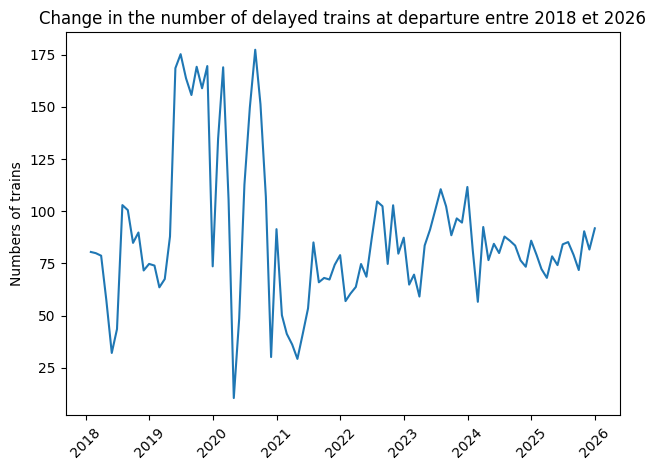

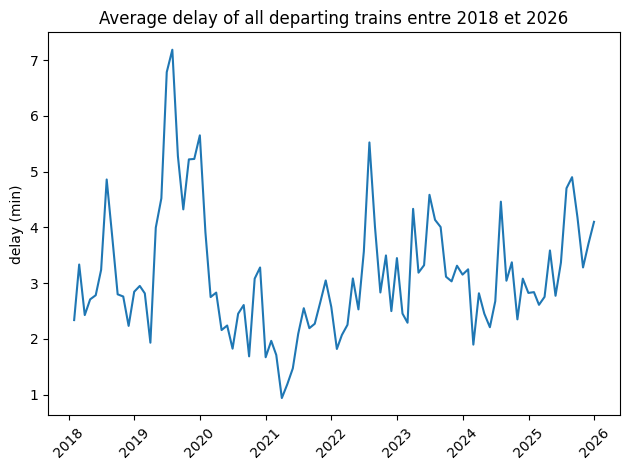

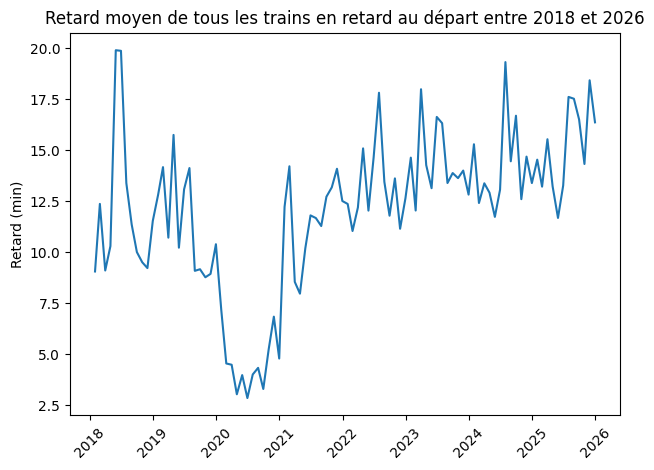

In [ ]:
import matplotlib.pyplot as plt

new_data = pd.DataFrame(pd.read_csv('cleaned_dataset.csv'))
new_data["Date"] = pd.to_datetime(new_data["Date"])
head = new_data.head(1000)

fig_1 = new_data.set_index("Date").resample("ME")[numbers_trains_delay_departure].mean()
fig_2 = new_data.set_index("Date").resample("ME")[average_trains_delay_departure].mean()
fig_3 = new_data.set_index("Date").resample("ME")[average_delay_trains_delay_departure].mean()

plt.figure()
plt.plot(fig_1.index, fig_1.values)
plt.title("Change in the number of delayed trains at departure between 2018 and 2026")
plt.ylabel("Numbers of trains")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(fig_2.index, fig_2.values)
plt.title("Average delay of all departing trains between 2018 and 2026")
plt.ylabel("Delay (min)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(fig_3.index, fig_3.values)
plt.title("Average delay of all trains departing late between 2018 and 2026")
plt.ylabel("Delay (min)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()